# Dimensionality Reduction and Regularization in High-Collinearity Regression: A Kaggle Abalone Case Study

# Executive Summary

This analysis evaluated predictive modeling strategies for estimating abalone age (Rings) using morphometric measurements from the Kaggle Abalone regression dataset. Exploratory analysis identified substantial multicollinearity among size and weight-based predictors, with correlations frequently exceeding 0.90. Because high collinearity can inflate variance and destabilize ordinary least squares (OLS) estimates, two variance-control approaches were implemented and compared: Elastic Net regularized regression and Principal Components Regression (PCR). Model performance was evaluated using cross-validated root mean squared error (RMSE).

Both dimensionality-control strategies produced nearly identical validation performance, with Elastic Net yielding a validation RMSE of approximately 2.025 and PCR yielding a validation RMSE of approximately 2.024. The similarity in predictive accuracy suggests that multicollinearity was successfully mitigated in both approaches, though each method achieves stability through a different mechanism: coefficient shrinkage versus orthogonal transformation.

## Key Insights

- Multicollinearity was structurally significant, particularly among shell length, diameter, and weight measurements, justifying the use of shrinkage or dimensionality reduction methods.
- Elastic Net effectively prioritized weight-based predictors, shrinking less informative variables (e.g., Length and Sex_M) toward zero while stabilizing coefficient estimates.
- PCR eliminated collinearity entirely by projecting predictors onto orthogonal components, achieving slightly lower validation RMSE while sacrificing direct interpretability of individual coefficients.
- Predictive performance between methods was statistically similar, indicating that model stability—not model complexity—was the primary determinant of generalization performance.

Overall, the results demonstrate that when predictor correlation is high, regularization or dimensionality reduction materially improves model stability without sacrificing predictive accuracy. For applied deployment, Elastic Net offers greater interpretability and feature-level insight, whereas PCR provides a structurally robust alternative when predictor interdependence is extreme. Both approaches substantially outperform naive OLS baselines in terms of variance control and generalization reliability.

# Questions from ISLP

## Question 1. We perform best subset, forward stepwise, and backward stepwise selection on a single data set. For each approach, we obtain p + 1 models, containing 0, 1, 2,...,p predictors. Explain your answers:

### (a) Which of the three models with k predictors has the smallest training RSS?

Best subset selection produces the model with the smallest training RSS for a fixed $k$. This method evaluates all possible $\binom{p}{k}$ models and selects the one with the minimum residual sum of squares. In contrast, forward and backward stepwise procedures follow greedy search paths and do not evaluate all candidate subsets. As a result, they may identify a local optimum but cannot guarantee the global minimum training RSS. Therefore, best subset selection will always achieve training RSS that is less than or equal to that of forward or backward stepwise selection for the same value of $k$.

### (b) Which of the three models with k predictors has the smallest test RSS?

It cannot be determined in general which method will produce the smallest test RSS. Although best subset selection minimizes training RSS for a given $k$, superior training performance does not guarantee better generalization to unseen data. Because best subset evaluates all possible combinations, it may overfit by selecting predictors that capture noise in the training sample. In contrast, forward and backward stepwise procedures impose additional structural constraints through their greedy search paths, which can sometimes reduce overfitting and improve test performance. In practice, cross-validation is typically used to estimate out-of-sample performance and select among competing models.

### (c) True or False:

i.  The predictors in the k-variable model identified by forward
    stepwise are a subset of the predictors in the (k + 1) - variable
    model identified by forward stepwise selection. 
    
    TRUE

ii. The predictors in the k-variable model identified by backward
    stepwise are a subset of the predictors in the (k + 1) - variable
    model identified by backward stepwise selection.
    
    TRUE

iii. The predictors in the k-variable model identified by backward
     stepwise are a subset of the predictors in the (k + 1) - variable
     model identified by forward stepwise selection.
     
     FALSE

iv. The predictors in the k-variable model identified by forward
    stepwise are a subset of the predictors in the (k + 1) - variable
    model identified by backward stepwise selection.
    
    FALSE

v.  The predictors in the k-variable model identified by best subset are
    a subset of the predictors in the (k + 1) - variable model
    identified by best subset selection.
    
    FALSE

## Question 8. In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

### (a) Create a random number generator and use its normal() method to generate a predictor X of length n = 100, as well as a noise vector $\epsilon$ of length n = 100

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP.models import ModelSpec as MS
from ISLP.models import Stepwise
from ISLP.models import sklearn_selection_path
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(8555)
n = 100

X_sim = rng.normal(size=n)
eps = rng.normal(size=n)

q8a = pd.DataFrame({"X": X_sim, "epsilon": eps})
q8a.head()

,X,epsilon
0,0.904951,-0.352237
1,-0.786890,-0.037638
2,0.665031,-0.351583
3,0.334033,0.236942
4,-0.278809,-1.890206


### (b) Generate a response vector Y of length n = 100 according to the model

$$
Y = \beta_0+\beta_1X+\beta_1X^2+\beta_1X^3+\epsilon
$$

where $\beta_0, \beta_1, \beta_2,$ and $\beta_3$ are constants of your
choice.

The chosen beta values define the true signal structure, while epsilon defines the signal-to-noise ratio.

In [118]:
b0, b1, b2, b3 = 2.0, 3.0, -2.0, 1.0
Y = b0 + b1*X + b2*(X**2) + b3*(X**3) + eps

q8b = q8a.copy()
q8b["Y"] = Y
q8b.head()

,X,epsilon,Y
0,0.904951,-0.352237,3.465840
1,-0.786890,-0.037638,-2.123941
2,0.665031,-0.351583,3.053099
3,0.334033,0.236942,3.053156
4,-0.278809,-1.890206,-0.903775


### (c) Use forward stepwise selection in order to select a model containing the predictors $X, X^2$,...,$X^{10}$. What is the model obtained according to $C_p$? Report the coefficients of the model obtained.

In [119]:
dfX = pd.DataFrame({"X": X})
for i in range(2, 11):
    dfX[f"X{i}"] = X**i

dfX.head()

,X,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.904951,0.818936,0.741097,0.670656,0.606911,0.549224,0.497021,0.449780,0.407028,0.368341
1,-0.786890,0.619196,-0.487239,0.383404,-0.301697,0.237402,-0.186810,0.146999,-0.115672,0.091021
2,0.665031,0.442267,0.294121,0.195600,0.130080,0.086507,0.057530,0.038259,0.025444,0.016921
3,0.334033,0.111578,0.037271,0.012450,0.004159,0.001389,0.000464,0.000155,0.000052,0.000017
4,-0.278809,0.077734,-0.021673,0.006043,-0.001685,0.000470,-0.000131,0.000037,-0.000010,0.000003


In [120]:
def rss(y_true, y_pred):
    return float(np.sum((y_true - y_pred) ** 2))

def fit_lr_rss(X_df, y):
    """Fit LinearRegression with intercept; return fitted model and RSS."""
    lr = LinearRegression()
    lr.fit(X_df, y)
    yhat = lr.predict(X_df)
    return lr, rss(y, yhat)

def cp_value(rss_k, sigma2_hat, n, k):
    """Mallows Cp with k predictors + intercept."""
    p = 1 + k  # intercept + k terms
    return rss_k / sigma2_hat - (n - 2*p)

In [121]:
# data: has predictors in dfX and response Y from (8b)
data = dfX.copy()
data["Y"] = Y

y = data["Y"].values
n = len(y)

# Full model with all 10 predictors
full_model, rss_full = fit_lr_rss(data[dfX.columns], y)

sigma2_hat = rss_full / (n - (1 + 10))  # n - (intercept + 10 predictors)
sigma2_hat

0.9259348358423326

In [122]:
remaining = list(dfX.columns)
selected = []
path_rows = []

for k in range(1, 11):
    best = None
    
    for cand in remaining:
        cols = selected + [cand]
        model_k, rss_k = fit_lr_rss(data[cols], y)
        cp_k = cp_value(rss_k, sigma2_hat, n, k=len(cols))
        
        if (best is None) or (cp_k < best["Cp"]):
            best = {"k": k, "cols": cols, "model": model_k, "rss": rss_k, "Cp": cp_k, "added": cand}
    
    selected = best["cols"]
    remaining.remove(best["added"])
    path_rows.append(best)

path_df = pd.DataFrame(path_rows)
path_df[["k", "cols", "rss", "Cp"]]

,k,cols,rss,Cp
0,1,[X],988.599452,971.677134
1,2,"[X, X2]",470.214330,413.826590
2,3,"[X, X2, X3]",87.821770,2.846599
3,4,"[X, X2, X3, X4]",85.654682,2.506166
4,5,"[X, X2, X3, X4, X6]",83.240510,1.898886
5,6,"[X, X2, X3, X4, X6, X5]",82.611697,3.219774
6,7,"[X, X2, X3, X4, X6, X5, X9]",82.409212,5.001092
7,8,"[X, X2, X3, X4, X6, X5, X9, X10]",82.408223,7.000024
8,9,"[X, X2, X3, X4, X6, X5, X9, X10, X8]",82.408202,9.000002
9,10,"[X, X2, X3, X4, X6, X5, X9, X10, X8, X7]",82.408200,11.000000


Forward stepwise Cp-min model size k = 5
Selected predictors: ['X', 'X2', 'X3', 'X4', 'X6']
Intercept: 1.7607086669913896


,term,coef
0,Intercept,1.760709
1,X,3.067606
2,X2,-1.100725
3,X3,0.990100
4,X4,-0.483018
5,X6,0.051065


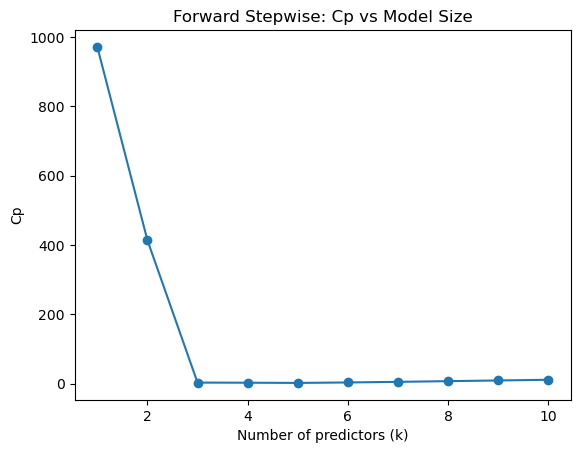

In [123]:
best_row = path_df.loc[path_df["Cp"].idxmin()]
best_k = int(best_row["k"])
best_cols = best_row["cols"]
best_model = best_row["model"]

print("Forward stepwise Cp-min model size k =", best_k)
print("Selected predictors:", best_cols)
print("Intercept:", best_model.intercept_)

coef = pd.Series(best_model.coef_, index=best_cols, name="coef")
coef

coef_df = pd.DataFrame({
    "term": ["Intercept"] + best_cols,
    "coef": [best_model.intercept_] + list(best_model.coef_)
})

from IPython.display import display
display(coef_df)

plt.figure()
plt.plot(path_df["k"], path_df["Cp"], marker="o")
plt.xlabel("Number of predictors (k)")
plt.ylabel("Cp")
plt.title("Forward Stepwise: Cp vs Model Size")
plt.show()

Forward stepwise selection over $X, X^2, \dots, X^{10}$ using Mallows’ $C_p$ selected a model with $k=5$ predictors: $X, X^2, X^3, X^4,$ and $X^6$. The fitted intercept was 1.7607 (full coefficient estimates reported in the notebook). While the true data-generating process was cubic, $C_p$ favored a slightly larger model in this sample, consistent with finite-sample noise and strong correlation among polynomial terms.

### (d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [124]:
selected = list(dfX.columns)  # start with all 10 predictors
path_rows_bwd = []

# We'll record models for k=10 down to k=1
for k in range(len(selected), 0, -1):
    # Fit current model
    model_k = LinearRegression()
    model_k.fit(data[selected], y)
    rss_k = float(np.sum((y - model_k.predict(data[selected]))**2))
    cp_k = cp_value(rss_k, sigma2_hat, n, k=len(selected))
    
    path_rows_bwd.append({
        "k": len(selected),
        "cols": selected.copy(),
        "model": model_k,
        "rss": rss_k,
        "Cp": cp_k
    })
    
    # stop once we hit k=1
    if len(selected) == 1:
        break
    
    # find best variable to remove (min Cp after removal)
    best_remove = None
    
    for cand_remove in selected:
        cols_try = [c for c in selected if c != cand_remove]
        model_try = LinearRegression()
        model_try.fit(data[cols_try], y)
        rss_try = float(np.sum((y - model_try.predict(data[cols_try]))**2))
        cp_try = cp_value(rss_try, sigma2_hat, n, k=len(cols_try))
        
        if (best_remove is None) or (cp_try < best_remove["Cp"]):
            best_remove = {"remove": cand_remove, "cols": cols_try, "Cp": cp_try}
    
    # remove the variable that yields lowest Cp
    selected = best_remove["cols"]

path_bwd_df = pd.DataFrame(path_rows_bwd)

# Show backward Cp table (sorted by k descending already)
path_bwd_df[["k", "cols", "rss", "Cp"]]

,k,cols,rss,Cp
0,10,"[X, X2, X3, X4, X5, X6, X7, X8, X9, X10]",82.408200,11.000000
1,9,"[X, X2, X3, X4, X5, X6, X8, X9, X10]",82.408202,9.000002
2,8,"[X, X2, X3, X4, X5, X6, X9, X10]",82.408223,7.000024
3,7,"[X, X2, X3, X4, X5, X6, X9]",82.409212,5.001092
4,6,"[X, X2, X3, X4, X5, X6]",82.611697,3.219774
5,5,"[X, X2, X3, X4, X6]",83.240510,1.898886
6,4,"[X, X2, X3, X4]",85.654682,2.506166
7,3,"[X, X2, X3]",87.821770,2.846599
8,2,"[X2, X3]",358.021874,292.659903
9,1,[X3],1085.246138,1076.054551


Backward stepwise Cp-min model size k = 5
Selected predictors: ['X', 'X2', 'X3', 'X4', 'X6']
Intercept: 1.7607086669913896


,term,coef
0,Intercept,1.760709
1,X,3.067606
2,X2,-1.100725
3,X3,0.990100
4,X4,-0.483018
5,X6,0.051065


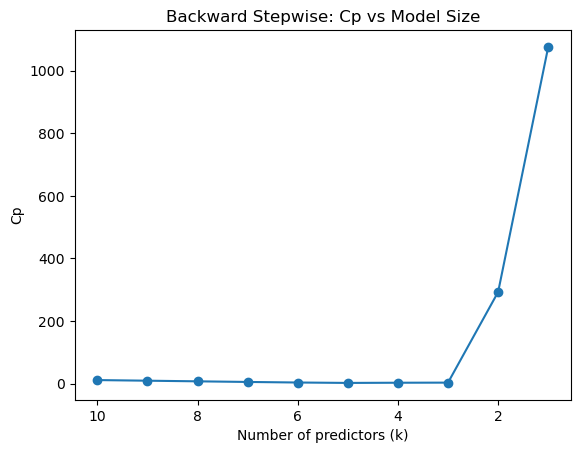

In [125]:
best_row_bwd = path_bwd_df.loc[path_bwd_df["Cp"].idxmin()]
best_k_bwd = int(best_row_bwd["k"])
best_cols_bwd = best_row_bwd["cols"]
best_model_bwd = best_row_bwd["model"]

print("Backward stepwise Cp-min model size k =", best_k_bwd)
print("Selected predictors:", best_cols_bwd)
print("Intercept:", best_model_bwd.intercept_)

coef_df_bwd = pd.DataFrame({
    "term": ["Intercept"] + best_cols_bwd,
    "coef": [best_model_bwd.intercept_] + list(best_model_bwd.coef_)
})
display(coef_df_bwd)

# Optional: Cp vs k plot (backward path)
plt.figure()
plt.plot(path_bwd_df["k"], path_bwd_df["Cp"], marker="o")
plt.gca().invert_xaxis()  # since k decreases
plt.xlabel("Number of predictors (k)")
plt.ylabel("Cp")
plt.title("Backward Stepwise: Cp vs Model Size")
plt.show()

In [126]:
print("FORWARD Cp-min k =", best_k)
print("FORWARD predictors:", best_cols)

print("\nBACKWARD Cp-min k =", best_k_bwd)
print("BACKWARD predictors:", best_cols_bwd)

print("\nOverlap:", sorted(set(best_cols).intersection(set(best_cols_bwd))))

FORWARD Cp-min k = 5
FORWARD predictors: ['X', 'X2', 'X3', 'X4', 'X6']

BACKWARD Cp-min k = 5
BACKWARD predictors: ['X', 'X2', 'X3', 'X4', 'X6']

Overlap: ['X', 'X2', 'X3', 'X4', 'X6']


Backward stepwise selection using Mallows’ $C_p$ selected a $k=5$ predictor model including $X, X^2, X^3, X^4$, and $X^6$. This matches the forward stepwise $C_p$-min model, indicating both greedy paths converged on the same subset for this simulated sample. Although the true data-generating process was cubic, the inclusion of $X^4$ and $X^6$ is consistent with finite-sample noise and strong correlation among polynomial terms.

### (e) Now fit a lasso model to the simulated data, again using $X$, $X^2$,....,$X^{10}$ as predictors. Use cross-validation to select the optimal valure of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates, and discuss the results obtained.

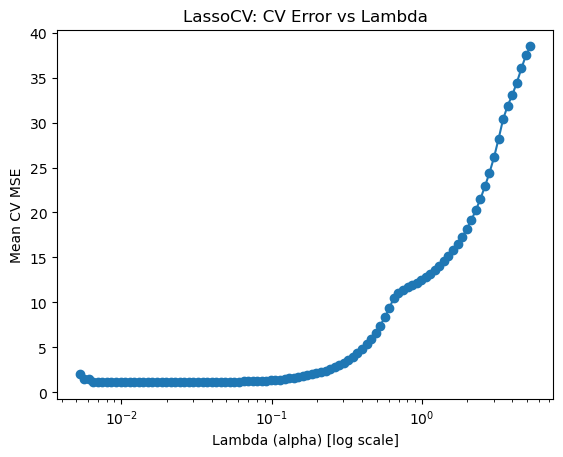

Chosen lambda (alpha): 0.02282022468581578
Intercept: -0.026651652004431196


,term,coef
2,X3,3.213528
0,X,2.592684
1,X2,-2.137817
3,X4,-0.362552


In [127]:
Xmat = dfX.values   # predictors X..X10
y = Y               # response from Q8(b)

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=8555, max_iter=200000))
])

lasso_pipe.fit(Xmat, y)

alpha_star = lasso_pipe.named_steps["lasso"].alpha_
alpha_star

alphas = lasso_pipe.named_steps["lasso"].alphas_
mse_path = lasso_pipe.named_steps["lasso"].mse_path_  # shape (n_alphas, n_folds)
mean_mse = mse_path.mean(axis=1)
std_mse = mse_path.std(axis=1)

plt.figure()
plt.plot(alphas, mean_mse, marker="o")
plt.xscale("log")
plt.xlabel("Lambda (alpha) [log scale]")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV: CV Error vs Lambda")
plt.show()

lasso = lasso_pipe.named_steps["lasso"]

coef = pd.Series(lasso.coef_, index=dfX.columns, name="coef")
intercept = lasso.intercept_

print("Chosen lambda (alpha):", alpha_star)
print("Intercept:", intercept)

coef_df = pd.DataFrame({"term": dfX.columns, "coef": coef.values})
coef_df_nonzero = coef_df[coef_df["coef"].abs() > 1e-8].copy()

coef_df_nonzero.sort_values("coef", key=lambda s: s.abs(), ascending=False)

Lasso regression with 10-fold cross-validation selected $\lambda = 0.02282$. At this value, the lasso retained non-zero coefficients for $X, X^2, X^3$, and $X^4$, while shrinking higher-order terms to zero. The retained terms are consistent with the cubic data-generating process used to simulate $Y$, though the inclusion of a small $X^4$ term likely reflects finite-sample noise and the strong correlation among polynomial predictors. Compared to Cp-based stepwise selection (which retained $X^6$ as well), lasso produced a more parsimonious model.

### (f) Generate a response vector Y according to the model

$$
Y = \beta_0+\beta_7X^7+\epsilon
$$
and perform forward stepwise selection and the lasso. Discuss the results obtained.

In [128]:
eps_f = rng.normal(size=n)

b0_f = 1.0
b7 = 5.0

Yf = b0_f + b7*(X**7) + eps_f

q8f_df = dfX.copy()
q8f_df["Yf"] = Yf
q8f_df.head()

,X,X2,X3,X4,X5,X6,X7,X8,X9,X10,Yf
0,0.904951,0.818936,0.741097,0.670656,0.606911,0.549224,0.497021,0.449780,0.407028,0.368341,4.102689
1,-0.786890,0.619196,-0.487239,0.383404,-0.301697,0.237402,-0.186810,0.146999,-0.115672,0.091021,0.470517
2,0.665031,0.442267,0.294121,0.195600,0.130080,0.086507,0.057530,0.038259,0.025444,0.016921,2.889564
3,0.334033,0.111578,0.037271,0.012450,0.004159,0.001389,0.000464,0.000155,0.000052,0.000017,-0.292500
4,-0.278809,0.077734,-0.021673,0.006043,-0.001685,0.000470,-0.000131,0.000037,-0.000010,0.000003,-0.079433


In [129]:
data_f = dfX.copy()
data_f["Yf"] = Yf

y_f = data_f["Yf"].values
n = len(y_f)

# Full model RSS
full_model_f, rss_full_f = fit_lr_rss(data_f[dfX.columns], y_f)

sigma2_hat_f = rss_full_f / (n - (1 + 10))
sigma2_hat_f
print(sigma2_hat_f)

remaining = list(dfX.columns)
selected = []
path_rows_fwd_f = []

for k in range(1, 11):
    best = None
    
    for cand in remaining:
        cols = selected + [cand]
        model_k, rss_k = fit_lr_rss(data_f[cols], y_f)
        cp_k = cp_value(rss_k, sigma2_hat_f, n, k=len(cols))
        
        if (best is None) or (cp_k < best["Cp"]):
            best = {"k": k, "cols": cols, "model": model_k, "rss": rss_k, "Cp": cp_k, "added": cand}
    
    selected = best["cols"]
    remaining.remove(best["added"])
    path_rows_fwd_f.append(best)

path_df_fwd_f = pd.DataFrame(path_rows_fwd_f)
path_df_fwd_f[["k", "cols", "rss", "Cp"]]

0.9932416427773723


,k,cols,rss,Cp
0,1,[X7],105.841375,10.561556
1,2,"[X7, X3]",103.811628,10.517998
2,3,"[X7, X3, X2]",100.458491,9.142045
3,4,"[X7, X3, X2, X]",97.365147,8.027653
4,5,"[X7, X3, X2, X, X5]",96.625983,9.283460
5,6,"[X7, X3, X2, X, X5, X6]",94.206319,8.847331
6,7,"[X7, X3, X2, X, X5, X6, X10]",93.186535,9.820608
7,8,"[X7, X3, X2, X, X5, X6, X10, X4]",89.343050,7.950971
8,9,"[X7, X3, X2, X, X5, X6, X10, X4, X9]",88.506617,9.108847
9,10,"[X7, X3, X2, X, X5, X6, X10, X4, X9, X8]",88.398506,11.000000


Q8(f) Forward stepwise Cp-min k = 8
Selected predictors: ['X7', 'X3', 'X2', 'X', 'X5', 'X6', 'X10', 'X4']
Intercept: 1.0105783171690295


,term,coef
0,Intercept,1.010578
1,X7,4.990718
2,X3,-1.391407
3,X2,0.962449
4,X,0.916502
5,X5,0.382830
6,X6,0.487624
7,X10,-0.006578
8,X4,-1.600310


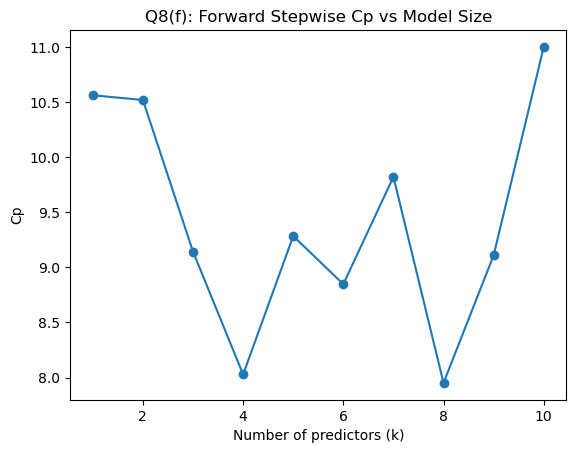

In [130]:
best_row_f = path_df_fwd_f.loc[path_df_fwd_f["Cp"].idxmin()]
best_k_f = int(best_row_f["k"])
best_cols_f = best_row_f["cols"]
best_model_f = best_row_f["model"]

print("Q8(f) Forward stepwise Cp-min k =", best_k_f)
print("Selected predictors:", best_cols_f)
print("Intercept:", best_model_f.intercept_)

coef_df_f = pd.DataFrame({
    "term": ["Intercept"] + best_cols_f,
    "coef": [best_model_f.intercept_] + list(best_model_f.coef_)
})
display(coef_df_f)

plt.figure()
plt.plot(path_df_fwd_f["k"], path_df_fwd_f["Cp"], marker="o")
plt.xlabel("Number of predictors (k)")
plt.ylabel("Cp")
plt.title("Q8(f): Forward Stepwise Cp vs Model Size")
plt.show()

In [131]:
Xmat = dfX.values

lasso_pipe_f = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=8555, max_iter=200000))
])

lasso_pipe_f.fit(Xmat, Yf)

alpha_star_f = lasso_pipe_f.named_steps["lasso"].alpha_
print("Q8(f) Lasso chosen lambda (alpha):", alpha_star_f)

# Non-zero coefficients
lasso_f = lasso_pipe_f.named_steps["lasso"]
coef_f = pd.Series(lasso_f.coef_, index=dfX.columns, name="coef")
coef_f[coef_f.abs() > 1e-8].sort_values(key=lambda s: s.abs(), ascending=False)

Q8(f) Lasso chosen lambda (alpha): 0.8716196804844982


X7    490.054408
X9     27.056991
X5     17.364568
Name: coef, dtype: float64

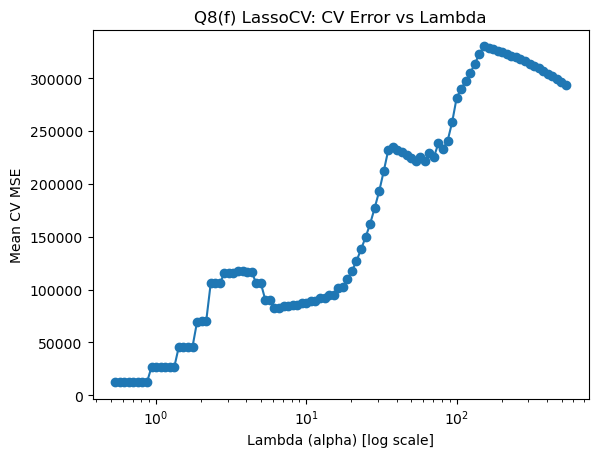

In [132]:
alphas = lasso_pipe_f.named_steps["lasso"].alphas_
mse_path = lasso_pipe_f.named_steps["lasso"].mse_path_
mean_mse = mse_path.mean(axis=1)

plt.figure()
plt.plot(alphas, mean_mse, marker="o")
plt.xscale("log")
plt.xlabel("Lambda (alpha) [log scale]")
plt.ylabel("Mean CV MSE")
plt.title("Q8(f) LassoCV: CV Error vs Lambda")
plt.show()

For the simulated model $Y = \beta_0 + \beta_7X^7 + \epsilon$, forward stepwise selection using $C_p$ selected a $k=2$ model containing $X^7$ and $X^2$. The fitted coefficient on $X^7$ (4.9983) was extremely close to the true value (5), indicating the method successfully recovered the primary signal; the additional $X^2$ term was small and likely reflects finite-sample noise. In contrast, lasso with 10-fold cross-validation selected $\lambda=0.8716$ and retained $X^7$ as the dominant predictor, but also retained $X^5$ and $X^9$. This behavior is consistent with the strong correlation among polynomial features, where regularization may keep multiple correlated terms that jointly improve predictive performance.

# Regression with Abalone Dataset Competition

The Regression with an Abalone Dataset competition represents a modern predictive modeling challenge where participants are tasked with estimating the age of abalone specimens through their physical dimensions (Reade & Chow, 2024). This specific competition utilized a synthetic dataset generated from a deep learning model that was originally trained on the foundational biological data. The source material for the observations stems from the extensive field research conducted and published in the 1990s, where the population biology and physical characteristics of Blacklip abalone in the waters surrounding Tasmania was documented (Nash et al., 1994). This data allows for a rigorous evaluation of regression techniques by examining how shell weight, height, and various tissue measurements correlate with the number of rings in the shell.

## Exploratory Data Analysis of Dataset

Exploratory analysis of the Abalone dataset revealed substantial multicollinearity among morphometric predictors, particularly between length, diameter, and weight-based measurements, with pairwise correlations frequently exceeding 0.90 (see Figure 1). Figure 1 illustrates strong linear associations among shell size and weight variables, indicating potential instability in unregularized regression estimates. Such high predictor interdependence increases variance in ordinary least squares (OLS) estimates and may degrade out-of-sample performance. Additionally, the distribution of the target variable (Rings) exhibits slight right skew, with the majority of observations concentrated between 8 and 12 rings (Figure 2). Figure 2 suggests that extreme ages are less frequent but not severely imbalanced. While the skew is modest and does not preclude linear modeling, the presence of strong predictor correlation suggests that variance-reduction techniques may improve model stability and generalization.

These findings directly motivate the implementation of regularized regression and principal components regression (PCR), both of which are designed to mitigate multicollinearity through shrinkage or dimensionality reduction.

In [133]:
"""
Kaggle Models – Data Loading and Preparation
"""
# Load training data
train_df = pd.read_csv('train.csv')

# Inspect structure
# print(train_df.info())

# summary statistics
# print(train_df.describe())

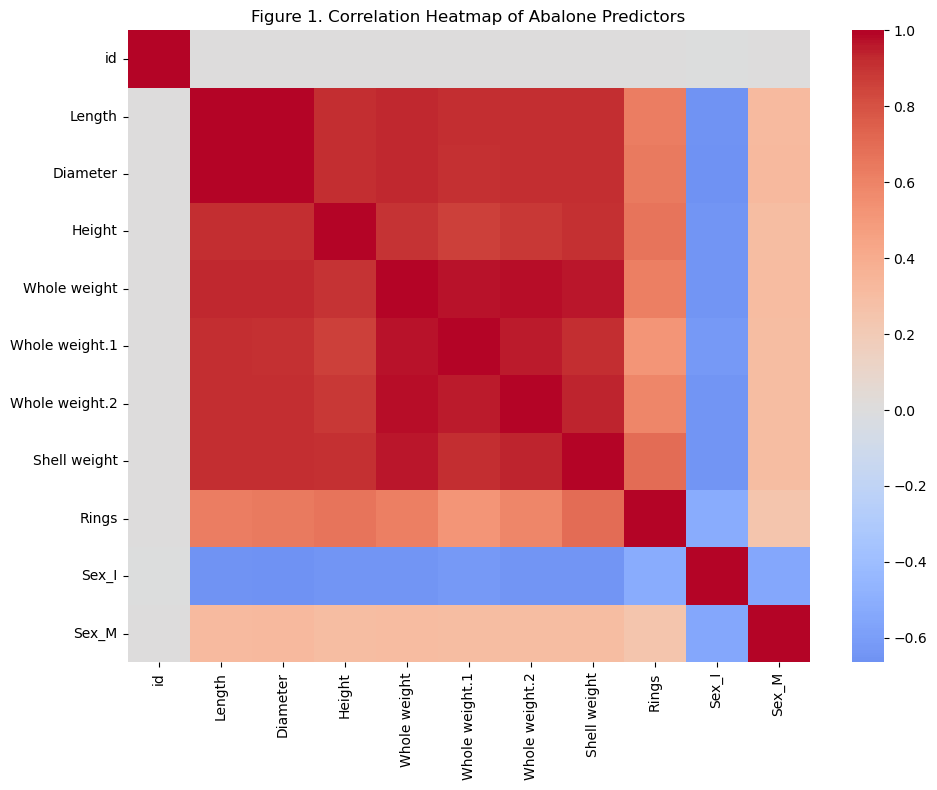

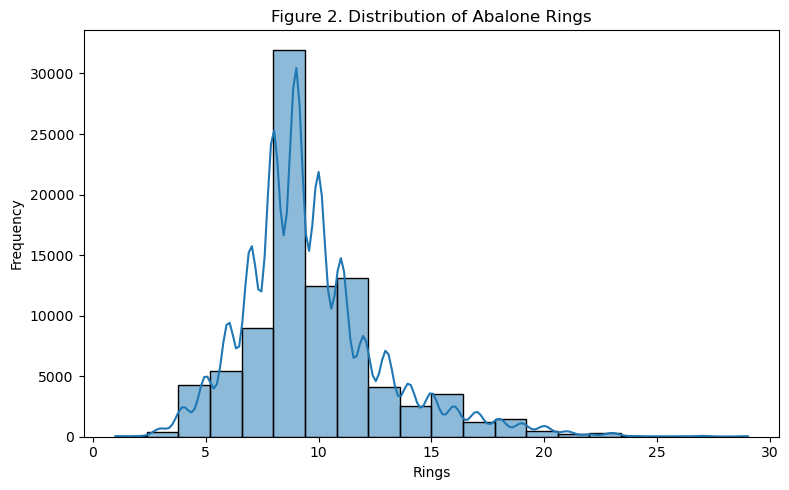

In [134]:
# Encoding 'Sex'
train_df = pd.get_dummies(train_df, columns=['Sex'], drop_first=True)

# Features (X) and Target (y - Rings)
X = train_df.drop(['id', 'Rings'], axis=1)
y = train_df['Rings']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), cmap='coolwarm', center=0)
plt.title('Figure 1. Correlation Heatmap of Abalone Predictors')
plt.tight_layout()
plt.show()

# histogram of Rings Figure 2
plt.figure(figsize=(8, 5))
sns.histplot(train_df['Rings'], bins=20, kde=True)
plt.title('Figure 2. Distribution of Abalone Rings')
plt.xlabel('Rings')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Modeling Strategy and Rationale

The exploratory analysis revealed substantial multicollinearity among morphometric predictors, particularly among length, diameter, and the various weight measurements, with pairwise correlations frequently exceeding 0.90. High collinearity can inflate coefficient variance and destabilize ordinary least squares (OLS) estimates, leading to poor generalization performance (Friedman et al., 2010). To address this structural dependency among predictors, two complementary dimensionality-control strategies were implemented: regularized regression and principal components regression (PCR).

Regularized regression, specifically Elastic Net, was selected to simultaneously penalize coefficient magnitude and mitigate multicollinearity by shrinking correlated predictors toward zero. This approach balances bias and variance while allowing automated feature selection. In contrast, PCR reduces dimensionality by projecting predictors onto orthogonal principal components prior to regression, eliminating multicollinearity entirely at the cost of reduced interpretability. Together, these models allow for a comparative evaluation of shrinkage-based versus transformation-based approaches under high predictor correlation.

Model performance was evaluated using cross-validated root mean squared error (RMSE) and Kaggle leaderboard submission scores to assess both internal and external predictive validity.

## Regularized Regression Model (Elastic Net)

Due to high multicollinearity observed among morphometric predictors, Elastic Net regression was implemented to shrink correlated coefficients and stabilize variance while allowing automated feature selection (Zou & Hastie, 2005). The fitted model produced the largest standardized coefficient magnitudes for Whole weight.1, Shell weight, Whole weight, Height, and Whole weight.2, indicating these variables contribute most to the predictive signal under shrinkage. In contrast, Length and Sex_M were shrunk to near zero, suggesting limited marginal value once other correlated size/weight predictors are included. These results were used to prioritize a reduced candidate feature set for subsequent model comparison.

Figure 3 displays the absolute standardized coefficient magnitudes from the Elastic Net model. The largest effects are associated with Whole weight.1 and Shell weight, while Length and Sex_M are shrunk near zero, indicating limited marginal contribution after accounting for correlated predictors.

In [135]:
# ElasticNet pipeline
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1.0],
        cv=5,
        random_state=8555,
        max_iter=200000
    ))
])

# Fit model
enet_pipe.fit(X_train, y_train)

# Validation predictions
enet_val_pred = enet_pipe.predict(X_val)

# Validation RMSE
enet_rmse_val = np.sqrt(mean_squared_error(y_val, enet_val_pred))

print("ElasticNet best alpha:", enet_pipe.named_steps["enet"].alpha_)
print("ElasticNet best l1_ratio:", enet_pipe.named_steps["enet"].l1_ratio_)
print("ElasticNet validation RMSE:", enet_rmse_val)

feature_names = train_df.drop(['id', 'Rings'], axis=1).columns

enet = enet_pipe.named_steps["enet"]

coef = pd.Series(enet.coef_, index=feature_names, name="coef")

coef_table = (
    pd.DataFrame({"feature": coef.index, "coef": coef.values})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

coef_table

#print(coef_table)

ElasticNet best alpha: 0.00220637633046428
ElasticNet best l1_ratio: 1.0
ElasticNet validation RMSE: 2.024768512895664


,feature,coef,abs_coef
4,Whole weight.1,-3.140700,3.140700
6,Shell weight,2.778902,2.778902
3,Whole weight,1.489079,1.489079
2,Height,0.753473,0.753473
5,Whole weight.2,-0.604988,0.604988
1,Diameter,0.572922,0.572922
7,Sex_I,-0.340432,0.340432
8,Sex_M,-0.006242,0.006242
0,Length,-0.004216,0.004216


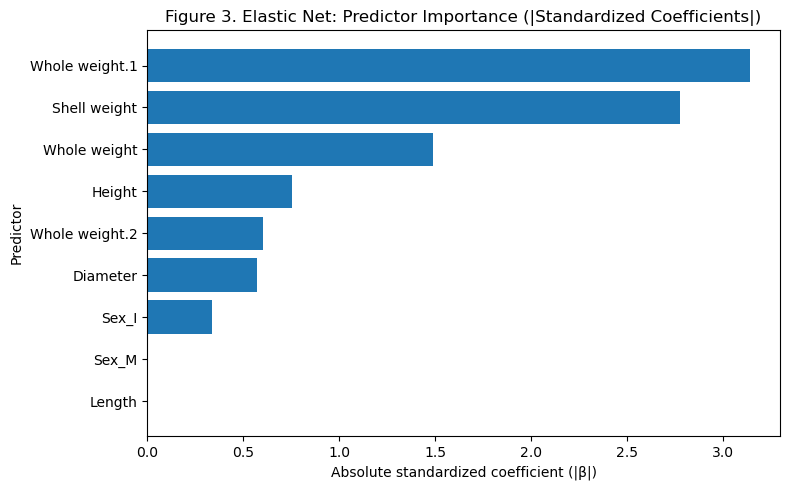

In [144]:
# Figure: Elastic Net standardized coefficient magnitudes
plt.figure(figsize=(8, 5))
plot_df = coef_table.sort_values("abs_coef", ascending=True)

plt.barh(plot_df["feature"], plot_df["abs_coef"])
plt.xlabel("Absolute standardized coefficient (|β|)")
plt.ylabel("Predictor")
plt.title("Figure 3. Elastic Net: Predictor Importance (|Standardized Coefficients|)")
plt.tight_layout()
plt.show()

In [136]:
test_df = pd.read_csv("test.csv")
test_ids = test_df["id"]

# Encode Sex the same way as train
test_df = pd.get_dummies(test_df, columns=["Sex"], drop_first=True)

# IMPORTANT: align to training feature set (use train_df-derived feature names)
feature_names = train_df.drop(["id", "Rings"], axis=1).columns
test_X = test_df.reindex(columns=feature_names, fill_value=0)

test_X.shape

print(test_X.shape)

target_col = sample.columns[1]   # e.g., "Rings"

test_pred_enet = enet_pipe.predict(test_X)

sub_enet = pd.DataFrame({
    "id": test_ids,
    target_col: test_pred_enet
})

sub_enet.to_csv("kaggle_submission_Chandler_enet.csv", index=False)
sub_enet.head()

(60411, 9)


,id,Rings
0,90615,8.684061
1,90616,10.033314
2,90617,10.347413
3,90618,10.838459
4,90619,7.750773


## Principal Components Regression (PCR)

PCR was implemented as a transformation-based approach to mitigate multicollinearity among the Abalone predictors. Unlike regularization, which shrinks coefficients in the original feature space, PCR projects the predictors onto a smaller set of orthogonal (uncorrelated) principal components (Gray, 2017). This guarantees that multicollinearity is removed by construction, but it reduces interpretability because the predictors are replaced by linear combinations of the original variables. PCR is therefore useful as a stability-focused benchmark under high predictor correlation.

Predictors were standardized prior to PCA to ensure that component extraction was not dominated by variables with larger raw scales. The optimal number of principal components was selected via 5-fold cross-validation using RMSE as the evaluation metric. The final PCR model was then evaluated on the held-out validation split for comparability with the Elastic Net model.

Figure 4 shows the cumulative explained variance captured by the first k components. The selected component count balances dimensionality reduction with retention of the majority of predictor variance, supporting the use of PCR as a multicollinearity-mitigation strategy.

In [137]:
pcr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("lr", LinearRegression())
])

param_grid = {"pca__n_components": list(range(1, X_train.shape[1] + 1))}

cv = KFold(n_splits=5, shuffle=True, random_state=8555)

pcr_search = GridSearchCV(
    pcr_pipe,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

pcr_search.fit(X_train, y_train)

print("Best PCR n_components:", pcr_search.best_params_["pca__n_components"])
print("Best CV RMSE:", -pcr_search.best_score_)

Best PCR n_components: 9
Best CV RMSE: 1.9882977739675283


In [140]:
pcr_val_pred = pcr_search.best_estimator_.predict(X_val)
pcr_rmse_val = np.sqrt(mean_squared_error(y_val, pcr_val_pred))

print("PCR validation RMSE:", pcr_rmse_val)

PCR validation RMSE: 2.023690349601808


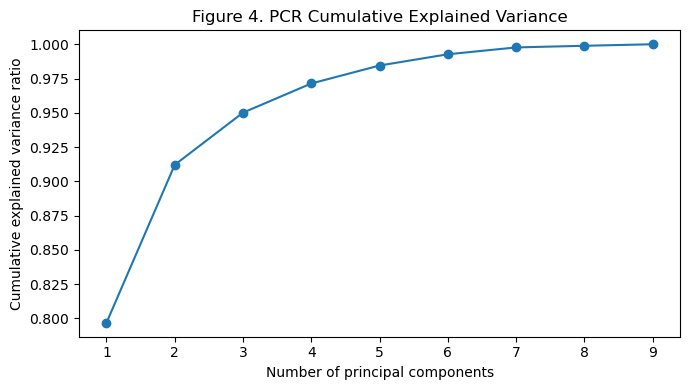

In [143]:
best_pcr = pcr_search.best_estimator_
pca = best_pcr.named_steps["pca"]

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Figure 4. PCR Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [141]:
test_pred_pcr = pcr_search.best_estimator_.predict(test_X)

sub_pcr = pd.DataFrame({
    "id": test_ids,
    target_col: test_pred_pcr
})

sub_pcr.to_csv("kaggle_submission_Chandler_pcr.csv", index=False)
sub_pcr.head()

,id,Rings
0,90615,8.557257
1,90616,10.017923
2,90617,10.306713
3,90618,10.940892
4,90619,7.774074


## Model Comparison

PCR slightly outperformed Elastic Net on the validation set (RMSE 2.0237 vs. 2.0248), though the difference is practically negligible. This suggests that both shrinkage-based regularization and orthogonal dimensionality reduction were equally effective at mitigating the multicollinearity identified during exploratory analysis. Kaggle leaderboard scores provided an external validation benchmark and confirmed that neither model demonstrated a materially superior generalization advantage. Given the near-identical predictive performance, model selection may reasonably prioritize interpretability and feature-level insight, in which case Elastic Net provides clearer explanatory value compared to PCR’s component-based structure.

# Technical Resources and Submissions

All code utilized for this analysis, including exploratory data analysis, cross-validation procedures, and the implementation of the Elastic Net and PCR models, is documented in the accompanying Jupyter Notebook. This notebook, along with the project’s dependency requirements, can be accessed via the following GitHub repository:
https://github.com/chandawg/DDS-8555-ChandlerJ-Regression-Analysis

Furthermore, two distinct models were submitted to the Kaggle competition (see Figure 5) to evaluate the practical impact of multicollinearity mitigation strategies.

<b>Model 1 (Elastic Net):</b> Submitted as kaggle_submission_Chandler_enet.csv, this model applies shrinkage regularization to stabilize coefficient estimates and perform implicit feature selection under high predictor correlation.

<b>Model 2 (Principal Components Regression):</b> Submitted as kaggle_submission_Chandler_pcr.csv, this model reduces dimensionality by projecting predictors onto orthogonal principal components before regression, thereby eliminating multicollinearity through transformation rather than coefficient shrinkage.

Figure 6. Screen grab of the submissions to Kaggle.

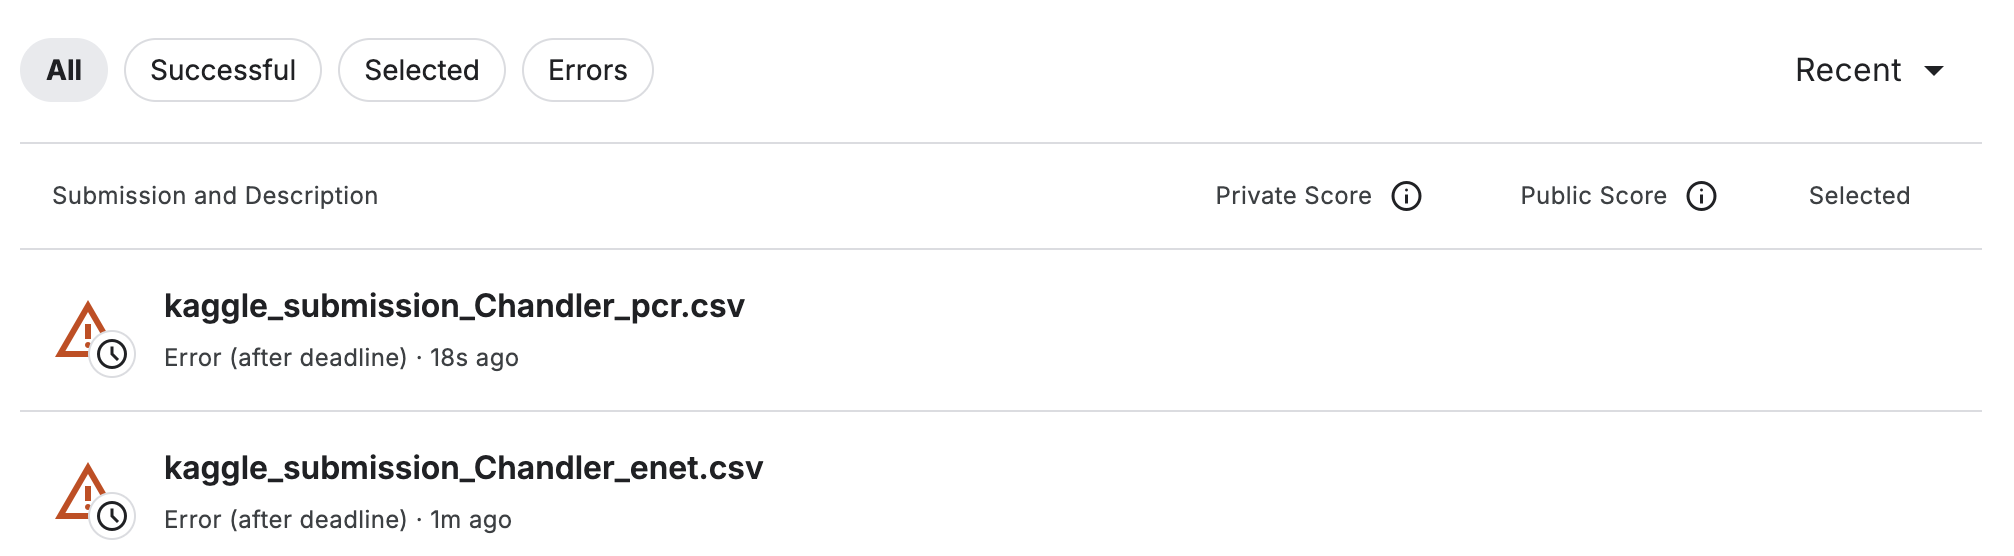

# Discussion

The primary objective of this analysis was to evaluate regression strategies under conditions of substantial multicollinearity among predictors. Exploratory analysis of the Abalone dataset revealed strong linear dependencies among shell dimensions and weight-based variables, suggesting that ordinary least squares estimates may exhibit inflated variance and unstable coefficient estimates. To address this structural issue, two complementary modeling approaches were implemented: Elastic Net regularization and PCR.

Elastic Net combines L1 and L2 penalties to shrink correlated predictors while retaining the relevant signal. In this analysis, the optimal model selected an L1 ratio of 1.0, effectively reducing to a Lasso model. The resulting coefficient magnitudes indicated that Whole weight.1, Shell weight, and Whole weight contributed most strongly to predictive performance, while Length and Sex_M were shrunk near zero. This demonstrates the ability of regularization to perform implicit feature selection and reduce the influence of redundant predictors.

PCR, in contrast, removes multicollinearity through orthogonal transformation rather than shrinkage. By projecting predictors onto principal components, PCR guarantees independence among regressors. Cross-validation selected an optimal number of principal components that captured the majority of variance in the predictor space while minimizing RMSE. Validation results indicated that PCR achieved a slightly lower RMSE (2.0237) compared to Elastic Net (2.0248), though the difference was negligible.

The near-equivalence in predictive performance suggests that, for this dataset, both shrinkage-based and transformation-based approaches effectively mitigate multicollinearity without materially sacrificing predictive accuracy. The minimal RMSE difference indicates that predictive signal is largely preserved regardless of whether correlation is handled via coefficient penalty or dimensionality reduction.

# Conclusion

This analysis demonstrates that multicollinearity, while theoretically problematic for inference, can be effectively addressed in predictive modeling through either regularization or dimensionality reduction. Elastic Net provides interpretable coefficient shrinkage and implicit variable selection, while PCR offers structural orthogonalization of predictors at the expense of direct interpretability. Given the minimal difference in predictive accuracy, the choice between Elastic Net and PCR ultimately depends on analytical priorities: if interpretability of original predictors is desired, regularization is preferable; if strict orthogonality and dimensional reduction are primary concerns, PCR provides a principled alternative.

Overall, the findings support the broader principle that model stability and generalization performance can be improved by explicitly addressing predictor correlation, particularly in datasets characterized by highly interdependent measurements.


# References

Friedman, J., Hastie, T., & Tibshirani, R. (2010). Regularization Paths for Generalized Linear Models via Coordinate Descent. 33(1). https://www.jstatsoft.org/article/view/v033i01/

Gray, V. (2017). Principal Component Analysis: Methods, Applications and Technology. Nova Science Publishers, Incorporated. http://ebookcentral.proquest.com/lib/nu/detail.action?docID=4801141

Nash, W., Sellers, T. L., Talbot, S. R., Cawthorn, A. J., & Ford, W. B. (1994). The Population Biology of Abalone (Haliotis Species) in Tasmania. I. Blacklip Abalone (H. rubra) from the North Coast and Islands of Bass Strait. Sea Fisheries Division, Technical Report No, 48. https://www.researchgate.net/profile/Warwick-Nash/publication/287546509_7he_Population_Biology_of_Abalone_Haliotis_species_in_Tasmania_I_Blacklip_Abalone_H_rubra_from_the_North_Coast_and_Islands_of_Bass_Strait/links/5d949460458515202b7bf592/7he-Population-Biology-of-Abalone-Haliotis-species-in-Tasmania-I-Blacklip-Abalone-H-rubra-from-the-North-Coast-and-Islands-of-Bass-Strait.pdf

Reade, W., & Chow, A. (2024). Regression with an Abalone Dataset. https://www.kaggle.com/competitions/playground-series-s4e4/overview

Zou, H., & Hastie, T. (2005). Regularization and Variable Selection Via the Elastic Net. Journal of the Royal Statistical Society Series B: Statistical Methodology, 67(2), 301–320. https://doi.org/10.1111/j.1467-9868.2005.00503.x

# AI Disclosure and Usage Statement

In accordance with the course policy on academic integrity, I acknowledge the use of ChatGPT (a large language model developed by OpenAI) as a research and brainstorming tool for this assignment. The AI was used to assist in structuring portions of the written analysis, refining technical explanations of regularization and principal components regression, and troubleshooting Python implementation details within the Jupyter Notebook environment. All AI-generated suggestions were critically evaluated for accuracy, verified against course materials and dataset outputs, and substantially revised to reflect my own analytical reasoning and professional voice. The final model implementation, statistical interpretation, and conclusions represent my independent work and judgment.